# Forecasting using ICOLD2022 data
This example shows how to use canari for forecasting the displacement of
a real dam by exploiting its dependency on the reservoir water level. ICOLD2022 data is used.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    plot_data,
    plot_prediction,
)
from canari.component import LstmNetwork, WhiteNoise

### Read data

In [ ]:
data_file = "../../data/icold2022/icold_2022.csv"

df_raw = pd.read_csv(data_file, delimiter=",", header=0,
                     names=["datetime","cb2","cb3","waterlevel","temp_a","temp_b"],
                     usecols=["datetime","cb2","waterlevel"],
                     index_col="datetime", parse_dates=True)

# Resample
df_raw = df_raw.loc['2000-01-30':'2012-12-31']
df = df_raw.resample("W").last()

### Hyper-parameter

In [ ]:
water_level_lag = 2  # Number of lagged values of the water level
look_back_len = 3    # Look-back length for LSTM, i.e., Number of lagged values of the displacement
sigma_v = 0.19654017672095225 # standard deviation for the noise component

### Data processing
We define here our choice of using the first 70% of the raw time series for trainig and the following 10% for the validaiton set. The remaining last 20% are the implicitely defined as the test set. "week_of_year" is used as time covariate.

In [ ]:
df_lagged = DataProcess.add_lagged_columns(df, [0, water_level_lag])
output_col = [0]
data_processor = DataProcess(
        data=df_lagged,
        time_covariates=["week_of_year"],
        train_split=0.7,
        validation_split=0.1,
        output_col=output_col,
    )
train_data, validation_data, test_data, _ = data_processor.get_splits()

### Model definition and training
The model is trained over 50 epochs with early-stopping, and the log-likelihood is reported for the validation period

In [ ]:
SEED = 1
NUM_EPOCH = 50

model = Model(
    LstmNetwork(
        look_back_len=look_back_len,
        num_features=data_processor.data.shape[1],
        num_layer=1,
        num_hidden_unit=50,
        manual_seed=SEED,
        smoother=False,
    ),
    WhiteNoise(std_error=sigma_v),
)

mu_validation_preds_optim = None
std_validation_preds_optim = None

for epoch in range(NUM_EPOCH):
    (mu_validation_preds, std_validation_preds, states) = model.lstm_train(
        train_data=train_data,
        validation_data=validation_data,
    )

    mu_validation_preds = normalizer.unstandardize(
        mu_validation_preds,
        data_processor.scale_const_mean[output_col],
        data_processor.scale_const_std[output_col],
    )
    std_validation_preds = normalizer.unstandardize_std(
        std_validation_preds,
        data_processor.scale_const_std[output_col],
    )

    validation_obs = data_processor.get_data("validation").flatten()
    validation_log_lik = metric.log_likelihood(
        prediction=mu_validation_preds,
        observation=validation_obs,
        std=std_validation_preds,
    )

    # Early-stopping on the validation set
    model.early_stopping(
        evaluate_metric=-validation_log_lik,
        current_epoch=epoch,
        max_epoch=NUM_EPOCH,
    )

    if epoch == model.optimal_epoch:
        mu_validation_preds_optim = mu_validation_preds
        std_validation_preds_optim = std_validation_preds

    if model.stop_training:
        break

### Forecast on the test set
In order to forecast on the test set, we need to set the LSTM and SSM states to the values corresponding to the last time step of the validation set. Note that the values corresponds to those associated with the optimal training epoch as identified using the validation set. Then, we perform recursive 1-step ahead forecasts on the test set and then proceed with un-standardization of the data in order to retreive the original scale of the raw data

In [ ]:
model.set_memory(time_step=data_processor.test_start - 1)

mu_test_preds, std_test_preds,_ = model.forecast(data=test_data)

mu_test_preds = normalizer.unstandardize(
    mu_test_preds,
    data_processor.scale_const_mean[output_col],
    data_processor.scale_const_std[output_col],
)
std_test_preds = normalizer.unstandardize_std(
    std_test_preds,
    data_processor.scale_const_std[output_col],
)

### Predictions

Text(0, 0.5, 'Water level [m]')

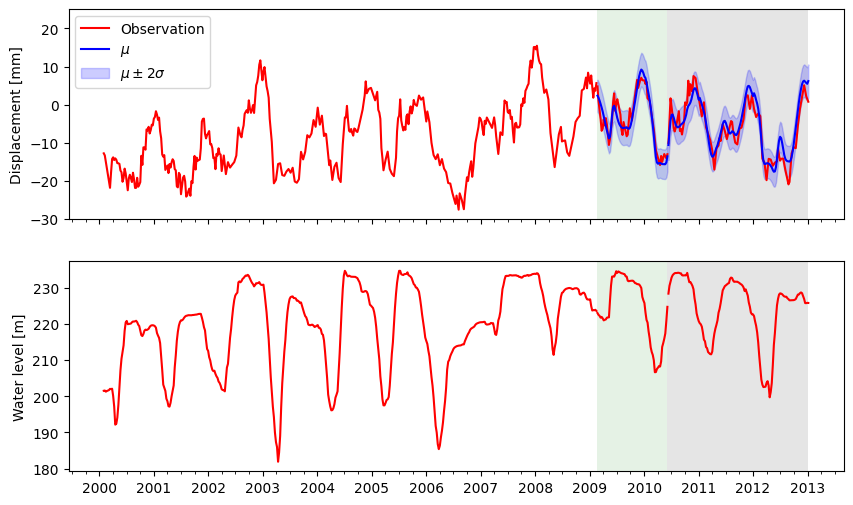

In [ ]:
# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=output_col,
    plot_nan=False,
    validation_label="Observation",
)
plot_prediction(
    data_processor=data_processor,
    mean_validation_pred=mu_validation_preds_optim,
    std_validation_pred=std_validation_preds_optim,
    validation_label=[r"$\mu$", r"$\mu \pm 2\sigma$"],
    color="blue",
    num_std=2,
)
plot_prediction(
    data_processor=data_processor,
    mean_test_pred=mu_test_preds,
    std_test_pred=std_test_preds,
    color="blue",
    num_std=2,
)
ax.grid(False, which="both", axis="x")
ax.set_ylim(-30, 25)
ax.set_ylabel("Displacement [mm]")
ax.legend()  

ax = axes[1]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=[1],
    plot_nan=False,
)

ax.grid(False, which="both", axis="x")
ax.set_ylabel("Water level [m]")